<a href="https://colab.research.google.com/github/SabhyaDwivedi/my-repository/blob/main/Final_Mod_2_Midcousre_WebScraping_ipynb_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Web Scraping & Data Handling Challenge**



### **Website:**
JustWatch -  https://www.justwatch.com/in/movies?release_year_from=2000


### **Description:**

JustWatch is a popular platform that allows users to search for movies and TV shows across multiple streaming services like Netflix, Amazon Prime, Hulu, etc. For this assignment, you will be required to scrape movie and TV show data from JustWatch using Selenium, Python, and BeautifulSoup. Extract data from HTML, not by directly calling their APIs. Then, perform data filtering and analysis using Pandas, and finally, save the results to a CSV file.

### **Tasks:**

**1. Web Scraping:**

Use BeautifulSoup to scrape the following data from JustWatch:

   **a. Movie Information:**

      - Movie title
      - Release year
      - Genre
      - IMDb rating
      - Streaming services available (Netflix, Amazon Prime, Hulu, etc.)
      - URL to the movie page on JustWatch

   **b. TV Show Information:**

      - TV show title
      - Release year
      - Genre
      - IMDb rating
      - Streaming services available (Netflix, Amazon Prime, Hulu, etc.)
      - URL to the TV show page on JustWatch

  **c. Scope:**

```
 ` - Scrape data for at least 50 movies and 50 TV shows.
   - You can choose the entry point (e.g., starting with popular movies,
     or a specific genre, etc.) to ensure a diverse dataset.`

```


**2. Data Filtering & Analysis:**

   After scraping the data, use Pandas to perform the following tasks:

   **a. Filter movies and TV shows based on specific criteria:**

   ```
      - Only include movies and TV shows released in the last 2 years (from the current date).
      - Only include movies and TV shows with an IMDb rating of 7 or higher.
```

   **b. Data Analysis:**

   ```
      - Calculate the average IMDb rating for the scraped movies and TV shows.
      - Identify the top 5 genres that have the highest number of available movies and TV shows.
      - Determine the streaming service with the most significant number of offerings.
      
   ```   

**3. Data Export:**

```
   - Dump the filtered and analysed data into a CSV file for further processing and reporting.

   - Keep the CSV file in your Drive Folder and Share the Drive link on the colab while keeping view access with anyone.
```

**Submission:**
```
- Submit a link to your Colab made for the assignment.

- The Colab should contain your Python script (.py format only) with clear
  comments explaining the scraping, filtering, and analysis process.

- Your Code shouldn't have any errors and should be executable at a one go.

- Before Conclusion, Keep your Dataset Drive Link in the Notebook.
```



**Note:**

1. Properly handle errors and exceptions during web scraping to ensure a robust script.

2. Make sure your code is well-structured, easy to understand, and follows Python best practices.

3. The assignment will be evaluated based on the correctness of the scraped data, accuracy of data filtering and analysis, and the overall quality of the Python code.








# **Start The Project**

## **Task 1:- Web Scrapping**

In [ ]:
#Installing all necessary labraries
!pip install bs4
!pip install requests

In [ ]:
#import all necessary labraries
import requests
from bs4 import BeautifulSoup
import re
import pandas as pd
import numpy as np
from datetime import datetime

## **Scrapping Movies Data**

In [ ]:
# Specifying the URL from which movies related data will be fetched

# WAS GETTING 403 ERROR, so took help online and found this piece of code so that it wont throw 403 error
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36',
    'Accept-Language': 'en-US,en;q=0.9',
    'Accept-Encoding': 'gzip, deflate, br',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
}
url='https://www.justwatch.com/in/movies?release_year_from=2000'

# Sending an HTTP GET request to the URL
response=requests.get(url, headers= headers)
# Parsing the HTML content using BeautifulSoup with the 'html.parser'
soup=BeautifulSoup(response.text,'html.parser')
# Printing the prettified HTML content
print(soup.prettify())

<!DOCTYPE html>
<html data-vue-meta="%7B%22dir%22:%7B%22ssr%22:%22ltr%22%7D,%22lang%22:%7B%22ssr%22:%22en%22%7D%7D" data-vue-meta-server-rendered="" dir="ltr" lang="en">
 <head>
  <meta charset="utf-8"/>
  <meta content="IE=edge" http-equiv="X-UA-Compatible"/>
  <meta charset="utf-8" data-vue-meta="ssr"/>
  <meta content="IE=edge" data-vue-meta="ssr" httpequiv="X-UA-Compatible"/>
  <meta content="viewport-fit=cover, width=device-width, initial-scale=1.0, minimum-scale=1.0, maximum-scale=1.0, user-scalable=no" data-vue-meta="ssr" name="viewport"/>
  <meta content="JustWatch" data-vue-meta="ssr" property="og:site_name"/>
  <meta content="794243977319785" data-vue-meta="ssr" property="fb:app_id"/>
  <meta content="/appassets/img/JustWatch_logo_with_claim.png" data-vmid="og:image" data-vue-meta="ssr" property="og:image"/>
  <meta content="606" data-vmid="og:image:width" data-vue-meta="ssr" property="og:image:width"/>
  <meta content="302" data-vmid="og:image:height" data-vue-meta="ssr" pro

## **Fetching Movie URL's**

In [ ]:
# Write Your Code here
url_list=[]
for x in soup.find_all('a', class_="title-list-grid__item--link"):
  url_list.append('https://www.justwatch.com'+x['href'])

print(len(url_list))
print(url_list)

100
['https://www.justwatch.com/in/movie/pushpa-the-rule-part-2', 'https://www.justwatch.com/in/movie/lucky-baskhar', 'https://www.justwatch.com/in/movie/bhool-bhulaiyaa-3', 'https://www.justwatch.com/in/movie/pushpa', 'https://www.justwatch.com/in/movie/venom-3-2024', 'https://www.justwatch.com/in/movie/all-we-imagine-as-light', 'https://www.justwatch.com/in/movie/amaran-2024', 'https://www.justwatch.com/in/movie/red-one', 'https://www.justwatch.com/in/movie/stree-2', 'https://www.justwatch.com/in/movie/kishkkindha-kandam', 'https://www.justwatch.com/in/movie/kanguva', 'https://www.justwatch.com/in/movie/singham-again-2024-0', 'https://www.justwatch.com/in/movie/bagheera-2024', 'https://www.justwatch.com/in/movie/the-substance', 'https://www.justwatch.com/in/movie/ore-dake-level-up-na-ken-reawakening', 'https://www.justwatch.com/in/movie/ntr-30', 'https://www.justwatch.com/in/movie/the-wild-robot', 'https://www.justwatch.com/in/movie/deadpool-3', 'https://www.justwatch.com/in/movie/al

## **Scrapping Movie Title**

In [ ]:
# Write Your Code here

movie_title = []

for url in url_list:
  try:
    response = requests.get(url, headers = headers)
    soup = BeautifulSoup(response.text,'html.parser')
    title=soup.find_all('h1')[0].text
  except:
    title='NA'

  movie_title.append(title)


print(movie_title)
print(len(movie_title))

[' Pushpa 2 - The Rule (2024)', ' Lucky Baskhar (2024)', ' Bhool Bhulaiyaa 3 (2024)', ' Pushpa: The Rise (2021)', ' Venom: The Last Dance (2024)', ' All We Imagine as Light (2024)', ' Amaran (2024)', ' Red One (2024)', ' Stree 2: Sarkate Ka Aatank (2024)', ' Kishkindha Kaandam (2024)', ' Kanguva (2024)', ' Singham Again (2024)', ' Bagheera (2024)', ' The Substance (2024)', ' Solo Leveling -ReAwakening- (2024)', ' Devara Part 1 (2024)', ' The Wild Robot (2024)', ' Deadpool & Wolverine (2024)', ' Alien: Romulus (2024)', ' Vicky Vidya Ka Woh Wala Video (2024)', ' Sookshma Darshini (2024)', ' Sikandar Ka Muqaddar (2024)', ' Carry-On (2024)', ' Jigra (2024)', ' Vettaiyan (2024)', ' Martin (2024)', ' Gladiator (2000)', ' Thangalaan (2024)', ' The Sabarmati Report (2024)', ' Meiyazhagan (2024)', ' Salaar (2023)', ' Black (2024)', ' We Live in Time (2024)', ' Naughty (2023)', ' KA (2024)', ' 365 Days (2020)', ' Smile 2 (2024)', ' The Reader (2008)', ' Zebra (2024)', ' A Quiet Place: Day One (2

## **Scrapping release Year**

In [ ]:
# Write Your Code here
movie_year=[]

for url in url_list:
  try:
    response=requests.get(url,headers=headers)
    soup=BeautifulSoup(response.text,'html.parser')
    year=soup.find_all('span',class_='release-year')[0].text.strip('()')
  except:
    year='NA'

  movie_year.append(year)

print(movie_year)
print(len(movie_year))

['2024', '2024', '2024', '2021', '2024', '2024', '2024', '2024', '2024', '2024', '2024', '2024', '2024', '2024', '2024', '2024', '2024', '2024', '2024', '2024', '2024', '2024', '2024', '2024', '2024', '2024', '2000', '2024', '2024', '2024', '2023', '2024', '2024', '2023', '2024', '2020', '2024', '2008', '2024', '2024', '2024', '2024', '2024', '2022', '2024', '2024', '2018', '2013', '2023', '2024', '2024', '2024', '2023', '2024', '2018', '2024', '2024', '2024', '2024', '2022', '2023', '2024', '2023', '2024', '2024', '2024', '2023', '2024', '2003', '2001', '2024', '2014', '2024', '2024', '2019', '2015', '2024', '2024', '2024', '2024', '2024', '2017', '2024', '2016', '2024', '2023', '2018', '2023', '2024', '2024', '2024', '2002', '2023', '2021', '2003', '2024', '2015', '2024', '2024', '2024']
100


## **Scrapping Genres**

In [ ]:
# Write Your Code here
movie_genre = []

for url in url_list:
  try:
    response = requests.get(url, headers=headers)
    soup=BeautifulSoup(response.text,'html.parser')
    for x in soup.find_all('div',class_='detail-infos'):
       if x.find_all('h3')[0].text=='Genres':
        genre=x.find_all('span')[0].text
  except:
    genre='NA'

  movie_genre.append(genre)


print(len(movie_genre))
print(movie_genre)


100
['Crime, Action & Adventure, Mystery & Thriller, Drama', 'Crime, Drama, Mystery & Thriller', 'Comedy, Horror', 'Action & Adventure, Drama, Mystery & Thriller, Crime', 'Science-Fiction, Mystery & Thriller, Action & Adventure', 'Drama, Romance', 'Drama, War & Military, Action & Adventure', 'Fantasy, Comedy, Action & Adventure', 'Comedy, Horror', 'Drama, Mystery & Thriller', 'Action & Adventure, Mystery & Thriller, Fantasy, Drama', 'Drama, Action & Adventure', 'Action & Adventure', 'Horror, Science-Fiction, Drama', 'Animation, Action & Adventure, Fantasy', 'Action & Adventure, Drama, Mystery & Thriller', 'Animation, Science-Fiction, Kids & Family, Action & Adventure', 'Comedy, Science-Fiction, Action & Adventure', 'Horror, Science-Fiction, Mystery & Thriller', 'Comedy', 'Mystery & Thriller', 'Mystery & Thriller, Action & Adventure, Crime, Drama', 'Action & Adventure, Mystery & Thriller, Crime', 'Crime, Drama, Mystery & Thriller, Action & Adventure', 'Crime, Drama, Action & Adventure',

## **Scrapping IMBD Rating**

In [ ]:
# Write Your Code here
movie_imdbrating=[]

for url in url_list:
  try:
     response=requests.get(url,headers=headers)
     soup=BeautifulSoup(response.text,'html.parser')
     for x in soup.find_all('div',class_='title-detail-hero-details__item'):
      imdbratings = soup.find_all('span', class_='imdb-score')
      if imdbratings:
        imdbrating = imdbratings[0].text.strip().split()[0]   # If we want all values IMDb then we can use code imdbrating = imdbratings[0].text.strip()
  except:
    imdbrating='NA'

  movie_imdbrating.append(imdbrating)


print(len(movie_imdbrating))
print(movie_imdbrating)

100
['6.6', '8.1', '5.1', '7.6', '6.0', '7.4', '8.3', '6.5', '7.0', '8.1', '4.7', '5.4', '6.8', '7.4', '8.1', '6.0', '8.2', '7.6', '7.1', '5.2', '8.1', '6.0', '6.5', '6.2', '7.1', '2.4', '8.5', '6.8', '6.6', '8.4', '6.6', '7.1', '7.0', '4.8', '7.2', '3.3', '6.8', '7.6', '8.4', '6.3', '4.5', '6.5', '8.0', '5.7', '7.6', '7.4', '8.2', '8.2', '6.1', '6.2', '6.8', '7.2', '6.8', '7.0', '8.2', '8.5', '6.7', '7.1', '7.1', '8.2', '8.3', '5.4', '7.7', '8.2', '7.1', '8.2', '6.5', '7.1', '8.3', '7.7', '7.5', '8.7', '6.5', '7.8', '6.8', '4.7', '7.6', '7.0', '6.5', '8.5', '7.1', '6.6', '7.1', '5.9', '7.2', '6.2', '7.7', '7.7', '6.9', '6.4', '5.3', '7.5', '8.8', '6.1', '8.1', '6.7', '4.2', '7.6', '5.8', '7.0']


## **Scrapping Runtime/Duration**

In [ ]:
# Write Your Code here
movie_runtime = []

for url in url_list:
  try:
    response = requests.get(url, headers=headers)
    soup=BeautifulSoup(response.text,'html.parser')
    for x in soup.find_all('div',class_='detail-infos'):
       if x.find_all('h3')[0].text=='Runtime':
        runtime=x.find_all('div')[0].text
  except:
    runtime='NA'

  movie_runtime.append(runtime)

print(len(movie_runtime))
print(movie_runtime)

100
['3h 18min', '2h 50min', '2h 38min', '2h 59min', '1h 49min', '1h 58min', '2h 47min', '2h 4min', '2h 27min', '2h 13min', '2h 34min', '2h 24min', '2h 38min', '2h 20min', '1h 56min', '2h 56min', '1h 42min', '2h 8min', '1h 59min', '2h 32min', '2h 22min', '2h 23min', '1h 59min', '2h 35min', '2h 43min', '2h 27min', '2h 35min', '2h 36min', '2h 7min', '2h 57min', '2h 55min', '2h 30min', '1h 48min', '1h 49min', '2h 31min', '1h 54min', '2h 7min', '2h 4min', '2h 44min', '1h 39min', '2h 31min', '2h 18min', '2h 19min', '2h 23min', '1h 45min', '2h 0min', '2h 36min', '3h 0min', '3h 21min', '2h 19min', '2h 28min', '2h 27min', '2h 29min', '1h 40min', '1h 44min', '2h 47min', '1h 58min', '1h 51min', '3h 0min', '2h 46min', '2h 26min', '2h 7min', '2h 7min', '1h 56min', '1h 59min', '2h 26min', '1h 37min', '1h 54min', '2h 0min', '2h 32min', '2h 29min', '2h 49min', '2h 7min', '2h 38min', '1h 58min', '1h 31min', '1h 44min', '1h 43min', '2h 3min', '2h 21min', '1h 37min', '1h 44min', '2h 33min', '1h 45min', 

## **Scrapping Age Rating**

In [ ]:
# Write Your Code here
movie_agerating=[]

for url in url_list:
  try:
     response=requests.get(url,headers=headers)
     soup=BeautifulSoup(response.text,'html.parser')
     age_rating = 'N.A.' #Default_value if age rating not found
     for x in soup.find_all('div',class_='detail-infos'):
       if x.find_all('h3')[0].text=='Age rating':
        age_rating=x.find_all('div')[0].text
  except:
    runtime='NA'#Default_value if age rating not found

  movie_agerating.append(age_rating)

print(len(movie_agerating))
print(movie_agerating)

100
['N.A.', 'UA', 'UA', 'UA', 'N.A.', 'A', 'N.A.', 'N.A.', 'UA', 'UA', 'UA', 'UA', 'UA', 'N.A.', 'N.A.', 'UA', 'N.A.', 'A', 'A', 'UA', 'N.A.', 'N.A.', 'N.A.', 'N.A.', 'UA', 'UA', 'N.A.', 'UA', 'UA', 'U', 'A', 'UA', 'N.A.', 'N.A.', 'N.A.', 'N.A.', 'N.A.', 'A', 'N.A.', 'N.A.', 'A', 'UA', 'N.A.', 'UA', 'A', 'N.A.', 'UA', 'A', 'A', 'UA', 'N.A.', 'UA', 'N.A.', 'N.A.', 'A', 'UA', 'N.A.', 'N.A.', 'UA', 'UA', 'A', 'N.A.', 'N.A.', 'N.A.', 'N.A.', 'U', 'UA', 'N.A.', 'A', 'U', 'A', 'UA', 'N.A.', 'N.A.', 'U', 'A', 'U', 'U', 'UA', 'N.A.', 'N.A.', 'A', 'N.A.', 'N.A.', 'UA', 'A', 'UA', 'UA', 'N.A.', 'UA', 'N.A.', 'A', 'N.A.', 'A', 'UA', 'N.A.', 'N.A.', 'N.A.', 'UA', 'N.A.']


## **Fetching Production Countries Details**

In [ ]:
# Write Your Code here
movie_productioncountries=[]

for url in url_list:
  try:
     content=requests.get(url,headers=headers)
     soup=BeautifulSoup(content.text,'html.parser')
     for x in soup.find_all('div', class_='detail-infos'):
      if x.find_all('h3')[0].text == ' Production country ':
        production_country = x.find_all('div')[0].text
  except:
    production_country='NA'

  movie_productioncountries.append(production_country)

print(len(movie_productioncountries))
print(movie_productioncountries)

100
['India', 'India', 'India', 'India', 'United States', 'Italy, Luxembourg, Netherlands, France, India', 'India', 'United States', 'India', 'India', 'India', 'India', 'India', 'France, United Kingdom', 'Japan', 'India', 'United States, Japan', 'United States', 'United Kingdom, United States, Hungary, Australia, New Zealand, Canada', 'India', 'India', 'India', 'United States', 'India', 'India', 'India', 'United Kingdom, United States', 'India', 'India', 'India', 'India', 'India', 'United Kingdom, France', 'Russia', 'India', 'Poland', 'United States', 'Germany, United States', 'India', 'United Kingdom, Canada, United States', 'India', 'India', 'United States', 'India', 'India', 'United Kingdom, United States', 'India', 'United States', 'India', 'India', 'Morocco, Canada, Malta, United States, United Kingdom', 'India', 'India', 'Canada, United States', 'India, Sweden', 'United States', 'United States', 'United States, Canada', 'India', 'India', 'India', 'United States', 'Denmark, German

## **Fetching Streaming Service Details**

In [ ]:
# Write Your Code here
movie_streaming_services=[]

for url in url_list:
  try:
     response=requests.get(url,headers=headers)
     soup=BeautifulSoup(response.text,'html.parser')
     names=(x['alt'] for x in soup.find_all('img', class_="offer__icon"))
  except:
    names='NA'

  movie_streaming_services.append(" , ".join(names))


print(len(movie_streaming_services))
print(movie_streaming_services)

100
['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']


## **Now Creating Movies DataFrame**

In [ ]:
# Write Your Code here
info_dict = {
    'url': url_list,
    'title': movie_title,
    'release_year': movie_year,
    'genre': movie_genre,
    'imdb_rating': movie_imdbrating,
    'runtime': movie_runtime,
    'age_rating': movie_agerating,
    'production_country': movie_productioncountries,
    'streaming_service': movie_streaming_services,
    'type': 'Movie'
}

movie_data=pd.DataFrame(info_dict)

In [ ]:
movie_data

,url,title,release_year,genre,imdb_rating,runtime,age_rating,production_country,streaming_service,type
0,https://www.justwatch.com/in/movie/bhool-bhula...,Bhool Bhulaiyaa 3 (2024),2024,"Comedy, Horror",5.2,2h 38min,UA,India,Bookmyshow,Movie
1,https://www.justwatch.com/in/movie/stree-2,Stree 2: Sarkate Ka Aatank (2024),2024,"Comedy, Horror",7.0,2h 27min,UA,India,"Amazon Prime Video , Amazon Prime Video , Amaz...",Movie
2,https://www.justwatch.com/in/movie/deadpool-3,Deadpool & Wolverine (2024),2024,"Comedy, Science-Fiction, Action & Adventure",7.7,2h 8min,A,United States,"Apple TV , Hotstar , Apple TV , Amazon Video ,...",Movie
3,https://www.justwatch.com/in/movie/ntr-30,Devara Part 1 (2024),2024,"Action & Adventure, Drama, Mystery & Thriller",6.1,2h 56min,UA,India,"Netflix , Bookmyshow",Movie
4,https://www.justwatch.com/in/movie/the-substance,The Substance (2024),2024,"Science-Fiction, Drama, Horror",7.4,2h 20min,UA,"United Kingdom, France","MUBI , MUBI Amazon Channel , Amazon Video",Movie
...,...,...,...,...,...,...,...,...,...,...
95,https://www.justwatch.com/in/movie/the-fall-guy,The Fall Guy (2024),2024,"Drama, Romance, Action & Adventure, Comedy",6.9,2h 6min,UA,"United States, Australia, Canada","Apple TV , Jio Cinema , Zee5 , Amazon Video , ...",Movie
96,https://www.justwatch.com/in/movie/ready-or-no...,Ready or Not (2019),2019,"Horror, Mystery & Thriller, Action & Adventure...",6.9,1h 35min,A,United States,"Apple TV , Netflix , Amazon Video , Apple TV",Movie
97,https://www.justwatch.com/in/movie/we-live-in-...,We Live in Time (2024),2024,"Romance, Drama, Comedy",7.1,1h 48min,A,"United Kingdom, France",Amazon Video,Movie
98,https://www.justwatch.com/in/movie/now-you-see-me,Now You See Me (2013),2013,"Mystery & Thriller, Crime",7.2,1h 56min,A,"France, United States","Amazon Prime Video , Apple TV , Amazon Prime V...",Movie


## **Scraping TV  Show Data**

In [ ]:
# Specifying the URL from which tv show related data will be fetched
tv_url='https://www.justwatch.com/in/tv-shows?release_year_from=2000'

# WAS GETTING 403 ERROR, so took help online and found this piece of code so that it wont throw 403 error
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36',
    'Accept-Language': 'en-US,en;q=0.9',
    'Accept-Encoding': 'gzip, deflate, br',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
}

# Sending an HTTP GET request to the URL
response=requests.get(tv_url, headers=headers)

# Parsing the HTML content using BeautifulSoup with the 'html.parser'
soup=BeautifulSoup(response.text,'html.parser')

# Printing the prettified HTML content
print(soup.prettify())

<!DOCTYPE html>
<html data-vue-meta="%7B%22dir%22:%7B%22ssr%22:%22ltr%22%7D,%22lang%22:%7B%22ssr%22:%22en%22%7D%7D" data-vue-meta-server-rendered="" dir="ltr" lang="en">
 <head>
  <meta charset="utf-8"/>
  <meta content="IE=edge" http-equiv="X-UA-Compatible"/>
  <meta charset="utf-8" data-vue-meta="ssr"/>
  <meta content="IE=edge" data-vue-meta="ssr" httpequiv="X-UA-Compatible"/>
  <meta content="viewport-fit=cover, width=device-width, initial-scale=1.0, minimum-scale=1.0, maximum-scale=1.0, user-scalable=no" data-vue-meta="ssr" name="viewport"/>
  <meta content="JustWatch" data-vue-meta="ssr" property="og:site_name"/>
  <meta content="794243977319785" data-vue-meta="ssr" property="fb:app_id"/>
  <meta content="/appassets/img/JustWatch_logo_with_claim.png" data-vmid="og:image" data-vue-meta="ssr" property="og:image"/>
  <meta content="606" data-vmid="og:image:width" data-vue-meta="ssr" property="og:image:width"/>
  <meta content="302" data-vmid="og:image:height" data-vue-meta="ssr" pro

## **Fetching Tv shows Url details**

In [ ]:
# Write Your Code here

tvshow_url=[]

for x in soup.find_all('a',class_="title-list-grid__item--link"):
  tvshow_url.append('https://www.justwatch.com'+x['href'])

print(len(tvshow_url))
print(tvshow_url)

100
['https://www.justwatch.com/in/tv-show/thukra-ke-mera-pyaar', 'https://www.justwatch.com/in/tv-show/from', 'https://www.justwatch.com/in/tv-show/the-day-of-the-jackal', 'https://www.justwatch.com/in/tv-show/mismatched', 'https://www.justwatch.com/in/tv-show/mirzapur', 'https://www.justwatch.com/in/tv-show/dune-the-sisterhood', 'https://www.justwatch.com/in/tv-show/secret-level', 'https://www.justwatch.com/in/tv-show/scam-1992', 'https://www.justwatch.com/in/tv-show/the-penguin', 'https://www.justwatch.com/in/tv-show/these-black-black-eyes', 'https://www.justwatch.com/in/tv-show/black-doves', 'https://www.justwatch.com/in/tv-show/game-of-thrones', 'https://www.justwatch.com/in/tv-show/solo-leveling-2024', 'https://www.justwatch.com/in/tv-show/yellowstone', 'https://www.justwatch.com/in/tv-show/cruel-intentions', 'https://www.justwatch.com/in/tv-show/aindham-vedham', 'https://www.justwatch.com/in/tv-show/citadel-honey-bunny', 'https://www.justwatch.com/in/tv-show/the-agency', 'https:

## **Fetching Tv Show Title details**

In [ ]:
# Write Your Code here
tvshow_title = []

for url in tvshow_url:
  try:
    response = requests.get(url, headers = headers)
    soup = BeautifulSoup(response.text,'html.parser')
    title=soup.find('h1',class_='title-detail-hero__details__title').text.strip()
  except:
    title='NA'

  tvshow_title.append(title)

print(tvshow_title)
print(len(tvshow_title))

['Thukra Ke Mera Pyaar (2024)', 'From (2022)', 'The Day of the Jackal (2024)', 'Mismatched (2020)', 'Mirzapur (2018)', 'Dune: Prophecy (2024)', 'Secret Level (2024)', 'Scam 1992: The Harshad Mehta Story (2020)', 'The Penguin (2024)', 'Yeh Kaali Kaali Ankhein (2022)', 'Black Doves (2024)', 'Game of Thrones (2011)', 'Solo Leveling (2024)', 'Yellowstone (2018)', 'Cruel Intentions (2024)', 'Aindham Vedham (2024)', 'Citadel: Honey Bunny (2024)', 'The Agency (2024)', 'The Pradeeps of Pittsburgh (2024)', 'Taaza Khabar (2023)', 'Arcane (2021)', 'Silo (2023)', 'When the Phone Rings (2024)', 'One Hundred Years of Solitude (2024)', 'Bigg Boss (2006)', 'Dan Da Dan (2024)', 'Light Shop (2024)', 'Farzi (2023)', 'XXX: Uncensored (2018)', 'Senna (2024)', 'Mastram (2020)', 'Panchayat (2020)', 'Campus Beats (2023)', 'Vikkatakavi (2024)', 'Attack on Titan (2013)', 'Breaking Bad (2008)', "Don't Come Home (2024)", 'Say Nothing (2024)', 'Superman & Lois (2021)', 'Creature Commandos (2024)', 'The Boys (2019)

## **Fetching Release Year**

In [ ]:
# Write Your Code here

tvshow_year=[]

for url in tvshow_url:
  try:
    response=requests.get(url,headers=headers)
    soup=BeautifulSoup(response.text,'html.parser')
    year=soup.find_all('span',class_='release-year')[0].text.strip('()')
  except:
    year='NA'

  tvshow_year.append(year)


print(tvshow_year)
print(len(tvshow_year))

['2024', '2022', '2024', '2020', '2018', '2024', '2024', '2020', '2024', '2022', '2024', '2011', '2024', '2018', '2024', '2024', '2024', '2024', '2024', '2023', '2021', '2023', '2024', '2024', '2006', '2024', '2024', '2023', '2018', '2024', '2020', '2020', '2023', '2024', '2013', '2008', '2024', '2024', '2021', '2024', '2019', '2021', '2022', '2021', '2023', '2024', '2024', '2019', '2018', '2024', '2024', '2019', '2018', '2024', '2023', '2024', '2024', '2022', '2017', '2021', '2017', '2024', '2010', '2018', '2024', '2014', '2021', '2009', '2020', '2011', '2024', '2013', '2005', '2020', '2024', '2024', '2019', '2014', '2024', '2019', '2022', '2019', '2021', '2019', '2024', '2004', '2023', '2024', '2024', '2018', '2014', '2016', '2019', '2004', '2002', '2013', '2022', '2017', '2015', '2016']
100


## **Fetching TV Show Genre Details**

In [ ]:
# Write Your Code here
tvshow_genre = []

for url in tvshow_url:
  try:
    response = requests.get(url, headers=headers)
    soup=BeautifulSoup(response.text,'html.parser')
    for x in soup.find_all('div',class_='detail-infos'):
       if x.find_all('h3')[0].text=='Genres':
        genre=x.find_all('span')[0].text
  except:
    genre='NA'

  tvshow_genre.append(genre)

print(len(tvshow_genre))
print(tvshow_genre)

100
['Romance', 'Mystery & Thriller, Drama, Horror, Science-Fiction', 'Crime, Drama, Mystery & Thriller, Action & Adventure', 'Comedy, Drama, Romance', 'Action & Adventure, Drama, Crime, Mystery & Thriller', 'Action & Adventure, Science-Fiction, Drama', 'Action & Adventure, Fantasy, Science-Fiction, Animation', 'Drama, Mystery & Thriller, Crime', 'Drama, Crime, Fantasy', 'Mystery & Thriller, Comedy, Crime, Drama', 'Mystery & Thriller, Crime, Action & Adventure, Drama', 'Science-Fiction, Drama, Action & Adventure, Fantasy', 'Action & Adventure, Fantasy, Animation, Science-Fiction', 'Western, Drama', 'Drama', 'Mystery & Thriller', 'Science-Fiction, Mystery & Thriller, Action & Adventure, Drama', 'Drama, Mystery & Thriller', 'Comedy, Drama', 'Science-Fiction, Drama, Fantasy, Mystery & Thriller, Action & Adventure, Comedy', 'Action & Adventure, Drama, Fantasy, Science-Fiction, Animation', 'Science-Fiction, Drama', 'Drama, Romance, Mystery & Thriller', 'Drama, Science-Fiction, Fantasy, Hist

## **Fetching IMDB Rating Details**

In [ ]:
# Write Your Code here
tvshow_rating = []

for url in tvshow_url:
  try:
    response = requests.get(url, headers = headers)
    soup = BeautifulSoup(response.text,'html.parser')
    for x in soup.find_all('div',class_='title-detail-hero-details__item'):
      imdbratings = soup.find_all('span', class_='imdb-score')
      if imdbratings:
        imdbrating = imdbratings[0].text.strip().split()[0]   # If we want all values of IMDb then we can use code imdbrating = imdbratings[0].text.strip()
      else:
        imdbrating='NA'
  except:
    imdbrating='NA'

  tvshow_rating.append(imdbrating)

print(len(tvshow_rating))
print(tvshow_rating)

100
['6.6', '7.8', '8.2', '5.9', '8.4', '7.3', '7.7', '9.2', '8.7', '7.0', '7.2', '9.2', '8.3', '8.6', '5.4', '7.3', '6.2', '7.2', '6.2', '8.1', '9.1', '8.1', '8.1', '8.6', '3.6', '8.7', '7.7', '8.3', '4.8', '8.3', '6.9', '9.0', '7.0', '7.7', '9.1', '9.5', '7.2', '8.3', '7.8', '7.8', '8.7', '5.8', '8.3', 'NA', '7.7', '7.7', '8.3', '7.1', '8.0', '6.4', '6.5', '8.6', '3.4', '6.7', 'NA', '8.1', '6.2', '8.0', '8.7', '7.8', '8.2', '7.2', '8.5', '8.2', '7.5', '8.3', '8.0', '8.5', '8.5', '8.5', '7.7', '6.5', '8.3', '6.6', 'NA', '8.2', '9.1', '7.8', '8.6', '8.3', '8.4', '7.8', '7.8', '9.3', '8.3', '8.3', '7.2', '7.2', '8.1', '8.4', '8.9', '8.0', '8.7', '8.7', '8.4', '8.7', '8.1', '7.7', '8.7', '8.7']


## **Fetching Age Rating Details**

In [ ]:
# Write Your Code here
tvshow_agerating=[]

for url in tvshow_url:
  try:
     response=requests.get(url,headers=headers)
     soup=BeautifulSoup(response.text,'html.parser')
     for x in soup.find_all('div',class_='detail-infos'):
       if x.find_all('h3')[0].text=='Age rating':
        age_rating=x.find_all('div')[0].text
  except:
    runtime='NA'

  tvshow_agerating.append(age_rating)

print(len(tvshow_agerating))
print(tvshow_agerating)

100
['N.A.', 'N.A.', 'N.A.', 'N.A.', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'U', 'U', 'U', 'U', 'U', 'U', 'U', 'U', 'U', 'U', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'UA', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'U', 'U', 'U', 'U', 'U', 'U', 'A', 'A', 'U', 'U', 'A', 'A', 'A', 'A', 'A', 'A', 'U', 'U', 'U', 'U', 'U', 'U', 'U', 'U', 'U', 'U', 'A', 'A', 'A', 'A', 'A']


## **Fetching Production Country details**

In [ ]:
# Write Your Code here
tvshow_productioncountries=[]

for url in tvshow_url:
  try:
     content=requests.get(url,headers=headers)
     soup=BeautifulSoup(content.text,'html.parser')
     for x in soup.find_all('div', class_='detail-infos'):
      if x.find_all('h3')[0].text == ' Production country ':
        production_country = x.find_all('div')[0].text
  except:
    production_country='NA'

  tvshow_productioncountries.append(production_country)


print(len(tvshow_productioncountries))
print(tvshow_productioncountries)

100
['India', 'United States', 'United Kingdom, United States', 'India', 'India', 'United States', 'United States', 'India', 'United States', 'India', 'United Kingdom', 'United States', 'Japan, South Korea', 'United States', 'United States', 'India', 'India', 'United States', 'Canada, United States', 'India', 'United States, France', 'United States', 'South Korea', 'Colombia', 'India', 'Japan', 'South Korea', 'India', 'India', 'Brazil', 'India', 'India', 'India', 'India', 'Japan', 'United States', 'Thailand', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'India', 'United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'India', 'Japan', 'India', 'United States', 'China', 'Japan', 'Thailand', 'United States', 'Germany', 'Japan', 'Spain', 'United States', 'United States', 'India', 'India', 'United States', 'South Korea', 'United States', 'Japan, United States', 'United States', 'United St

## **Fetching Streaming Service details**

In [ ]:
# Write Your Code here
tvshow_streaming_services=[]

for url in tvshow_url:
  try:
     response=requests.get(url,headers=headers)
     soup=BeautifulSoup(response.text,'html.parser')
     names=(x['alt'] for x in soup.find_all('img', class_="offer__icon"))
  except:
    names='NA'

  tvshow_streaming_services.append(" , ".join(names))


print(len(tvshow_streaming_services))
print(tvshow_streaming_services)

100
['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']


## **Fetching Duration Details**

In [ ]:
# Write Your Code here
tvshow_runtime = []

for url in tvshow_url:
  try:
    response = requests.get(url, headers=headers)
    soup=BeautifulSoup(response.text,'html.parser')
    for x in soup.find_all('div',class_='detail-infos'):
       if x.find_all('h3')[0].text=='Runtime':
        runtime=x.find_all('div')[0].text
  except:
    runtime='NA'

  tvshow_runtime.append(runtime)


print(len(tvshow_runtime))
print(tvshow_runtime)

100
['23min', '51min', '51min', '36min', '50min', '1h 5min', '15min', '52min', '58min', '40min', '54min', '58min', '24min', '51min', '42min', '34min', '50min', '49min', '28min', '32min', '41min', '49min', '1h 9min', '1h 5min', '1h 12min', '24min', '49min', '56min', '22min', '1h 3min', '28min', '35min', '29min', '38min', '25min', '47min', '45min', '43min', '42min', '23min', '1h 1min', '42min', '1h 2min', '44min', '46min', '30min', '49min', '34min', '43min', '49min', '1h 1min', '27min', '44min', '20min', '45min', '23min', '1h 14min', '40min', '56min', '24min', '57min', '35min', '54min', '24min', '36min', '1h 0min', '55min', '21min', '24min', '44min', '43min', '43min', '49min', '43min', '3min', '44min', '30min', '43min', '59min', '58min', '42min', '49min', '29min', '1h 5min', '50min', '43min', '29min', '57min', '1h 2min', '35min', '1h 1min', '47min', '45min', '44min', '23min', '58min', '24min', '19min', '24min', '1h 1min']


## **Creating TV Show DataFrame**

In [ ]:
# Write Your Code here
info_dict = {
    'url': tvshow_url,
    'title': tvshow_title,
    'release_year': tvshow_year,
    'genre': tvshow_genre,
    'imdb_rating': tvshow_rating,
    'runtime': tvshow_runtime,
    'age_rating': tvshow_agerating,
    'production_country': tvshow_productioncountries,
    'streaming_service': tvshow_streaming_services,
    'type': 'TV Show'
}

tv_data=pd.DataFrame(info_dict)

In [ ]:
tv_data

,url,title,release_year,genre,imdb_rating,runtime,age_rating,production_country,streaming_service,type
0,https://www.justwatch.com/in/tv-show/from,From (2022),2022,"Drama, Horror, Science-Fiction, Mystery & Thri...",7.8,51min,A,United States,"Amazon Prime Video , Amazon Prime Video",TV Show
1,https://www.justwatch.com/in/tv-show/the-penguin,The Penguin (2024),2024,"Drama, Crime, Fantasy",8.7,58min,A,United States,Jio Cinema,TV Show
2,https://www.justwatch.com/in/tv-show/citadel-h...,Citadel: Honey Bunny (2024),2024,"Action & Adventure, Drama, Science-Fiction, My...",6.2,50min,A,India,"Amazon Prime Video , Amazon Prime Video",TV Show
3,https://www.justwatch.com/in/tv-show/the-day-o...,The Day of the Jackal (2024),2024,"Crime, Drama, Mystery & Thriller, Action & Adv...",8.1,45min,A,"United Kingdom, United States",Jio Cinema,TV Show
4,https://www.justwatch.com/in/tv-show/dont-come...,Don't Come Home (2024),2024,"Mystery & Thriller, Drama, Horror, Science-Fic...",7.3,45min,A,Thailand,Netflix,TV Show
...,...,...,...,...,...,...,...,...,...,...
95,https://www.justwatch.com/in/tv-show/vikings,Vikings (2013),2013,"War & Military, Drama, History, Romance, Actio...",8.5,45min,A,Canada,Netflix,TV Show
96,https://www.justwatch.com/in/tv-show/adams-swe...,Adam's Sweet Agony (2024),2024,Animation,NA,3min,A,Japan,"Amazon Prime Video , Amazon Prime Video , Anim...",TV Show
97,https://www.justwatch.com/in/tv-show/tracker-2024,Tracker (2024),2024,"Drama, Crime",7.0,41min,A,United States,Hotstar,TV Show
98,https://www.justwatch.com/in/tv-show/the-flash,The Flash (2014),2014,"Drama, Science-Fiction, Action & Adventure",7.5,42min,U,United States,"Amazon Prime Video , Amazon Prime Video",TV Show


In [ ]:
# make a csv file
tv_data.to_csv('tv_data.csv')

In [ ]:
# Final Data
final_data=pd.concat([movie_data,tv_data],axis=0)
final_data

,url,title,release_year,genre,imdb_rating,runtime,age_rating,production_country,streaming_service,type
0,https://www.justwatch.com/in/movie/pushpa-the-...,Pushpa 2 - The Rule (2024),2024,"Crime, Action & Adventure, Mystery & Thriller,...",6.6,3h 18min,N.A.,India,,Movie
1,https://www.justwatch.com/in/movie/lucky-baskhar,Lucky Baskhar (2024),2024,"Crime, Drama, Mystery & Thriller",8.1,2h 50min,UA,India,,Movie
2,https://www.justwatch.com/in/movie/bhool-bhula...,Bhool Bhulaiyaa 3 (2024),2024,"Comedy, Horror",5.1,2h 38min,UA,India,,Movie
3,https://www.justwatch.com/in/movie/pushpa,Pushpa: The Rise (2021),2021,"Action & Adventure, Drama, Mystery & Thriller,...",7.6,2h 59min,UA,India,,Movie
4,https://www.justwatch.com/in/movie/venom-3-2024,Venom: The Last Dance (2024),2024,"Science-Fiction, Mystery & Thriller, Action & ...",6.0,1h 49min,N.A.,United States,,Movie
...,...,...,...,...,...,...,...,...,...,...
95,https://www.justwatch.com/in/tv-show/peaky-bli...,Peaky Blinders (2013),2013,"Drama, Crime",8.7,58min,A,United Kingdom,,TV Show
96,https://www.justwatch.com/in/tv-show/bluelock,BLUE LOCK (2022),2022,"Drama, Animation, Action & Adventure, Sport, M...",8.1,24min,A,Japan,,TV Show
97,https://www.justwatch.com/in/tv-show/young-she...,Young Sheldon (2017),2017,"Comedy, Drama",7.7,19min,A,United States,,TV Show
98,https://www.justwatch.com/in/tv-show/one-punch...,One-Punch Man (2015),2015,"Animation, Comedy, Action & Adventure, Kids & ...",8.7,24min,A,Japan,,TV Show


In [ ]:
final_data.to_csv('final_data.csv')

## **Task 2 :- Data Filtering & Analysis**

In [ ]:
# Write Your Code here
final_data1 = final_data.copy()
movie_data1 = movie_data.copy()
tv_data1 = tv_data.copy()

In [ ]:
print(final_data.head())

                                                 url  \
0  https://www.justwatch.com/in/movie/pushpa-the-...   
1   https://www.justwatch.com/in/movie/lucky-baskhar   
2  https://www.justwatch.com/in/movie/bhool-bhula...   
3          https://www.justwatch.com/in/movie/pushpa   
4    https://www.justwatch.com/in/movie/venom-3-2024   

                           title release_year  \
0     Pushpa 2 - The Rule (2024)         2024   
1           Lucky Baskhar (2024)         2024   
2       Bhool Bhulaiyaa 3 (2024)         2024   
3        Pushpa: The Rise (2021)         2021   
4   Venom: The Last Dance (2024)         2024   

                                               genre imdb_rating   runtime  \
0  Crime, Action & Adventure, Mystery & Thriller,...         6.6  3h 18min   
1                   Crime, Drama, Mystery & Thriller         8.1  2h 50min   
2                                     Comedy, Horror         5.1  2h 38min   
3  Action & Adventure, Drama, Mystery & Thriller,...    

In [ ]:
print(final_data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 0 to 99
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   url                 200 non-null    object
 1   title               200 non-null    object
 2   release_year        200 non-null    object
 3   genre               200 non-null    object
 4   imdb_rating         200 non-null    object
 5   runtime             200 non-null    object
 6   age_rating          200 non-null    object
 7   production_country  200 non-null    object
 8   streaming_service   200 non-null    object
 9   type                200 non-null    object
dtypes: object(10)
memory usage: 25.3+ KB
None


In [ ]:
# Only include movies and TV shows with an IMDb rating of 8 or higher
final_data1_ir = final_data1[final_data1['imdb_rating'] >= 8]
final_data1_ir

,url,title,release_year,genre,imdb_rating,runtime,age_rating,production_country,streaming_service,type
1,https://www.justwatch.com/in/movie/lucky-baskhar,Lucky Baskhar (2024),2024,"Crime, Drama, Mystery & Thriller",8.1,2h 50min,UA,India,,Movie
6,https://www.justwatch.com/in/movie/amaran-2024,Amaran (2024),2024,"Drama, War & Military, Action & Adventure",8.3,2h 47min,N.A.,India,,Movie
9,https://www.justwatch.com/in/movie/kishkkindha...,Kishkindha Kaandam (2024),2024,"Drama, Mystery & Thriller",8.1,2h 13min,UA,India,,Movie
14,https://www.justwatch.com/in/movie/ore-dake-le...,Solo Leveling -ReAwakening- (2024),2024,"Animation, Action & Adventure, Fantasy",8.1,1h 56min,N.A.,Japan,,Movie
16,https://www.justwatch.com/in/movie/the-wild-robot,The Wild Robot (2024),2024,"Animation, Science-Fiction, Kids & Family, Act...",8.2,1h 42min,N.A.,"United States, Japan",,Movie
...,...,...,...,...,...,...,...,...,...,...
94,https://www.justwatch.com/in/tv-show/naruto,Naruto (2002),2002,"Action & Adventure, Science-Fiction, Comedy, F...",8.4,23min,U,Japan,,TV Show
95,https://www.justwatch.com/in/tv-show/peaky-bli...,Peaky Blinders (2013),2013,"Drama, Crime",8.7,58min,A,United Kingdom,,TV Show
96,https://www.justwatch.com/in/tv-show/bluelock,BLUE LOCK (2022),2022,"Drama, Animation, Action & Adventure, Sport, M...",8.1,24min,A,Japan,,TV Show
98,https://www.justwatch.com/in/tv-show/one-punch...,One-Punch Man (2015),2015,"Animation, Comedy, Action & Adventure, Kids & ...",8.7,24min,A,Japan,,TV Show


In [ ]:
import os

In [ ]:
print(final_data1['release_year'].head())  # Check before cleaning
print(final_data1['release_year'].dtype)  # Verify type is numeric


0    2024
1    2024
2    2024
3    2021
4    2024
Name: release_year, dtype: int64
int64


In [ ]:
# basic check row and column
print(final_data1.shape)

(197, 10)


In [ ]:
# checking null value
final_data1.isnull().sum()

,0
url,0
title,0
release_year,0
genre,0
imdb_rating,0
runtime,0
age_rating,0
production_country,0
streaming_service,0
type,0


In [ ]:
final_data1.duplicated().sum()

0

In [ ]:
# statistical report
final_data1.describe()

,imdb_rating
count,197.000000
mean,7.354822
std,1.218036
min,2.400000
25%,6.700000
50%,7.600000
75%,8.300000
max,9.500000


## **Calculating Mean IMDB Ratings for both Movies and Tv Shows**

In [ ]:
# Write Your Code here
mean_rating = final_data1.groupby('type')['imdb_rating'].mean()

In [ ]:
print(f"Mean Imdb Rating,{mean_rating}")

Mean Imdb Rating,type
Movie      6.929000
TV Show    7.793814
Name: imdb_rating, dtype: float64


In [ ]:
# Convert 'imdb_rating' column to numeric, handling non-numeric values
tv_data1['imdb_rating'] = tv_data1['imdb_rating'].replace('NA', float("NaN"))
tv_data1['imdb_rating'] = tv_data1['imdb_rating'].astype(float)

# Calculate the mean IMDb rating for tv shows
tv_mean_rating = tv_data1.groupby('type')['imdb_rating'].mean()
print("Mean Imdb Rating")
print(tv_mean_rating)

Mean Imdb Rating
type
TV Show    7.793814
Name: imdb_rating, dtype: float64


In [ ]:
movie_data1['imdb_rating'] = movie_data1['imdb_rating'].replace('NA', float("NaN"))
movie_data1['imdb_rating'] = movie_data1['imdb_rating'].astype(float)

# Calculate the mean IMDb rating for movies
movie_mean_rating = movie_data1.groupby('type')['imdb_rating'].mean()
print("Mean Imdb Rating")
print(movie_mean_rating)

Mean Imdb Rating
type
Movie    6.929
Name: imdb_rating, dtype: float64


## **Analyzing Top Genres**

In [ ]:
# Write Your Code here
# for both movies and tv shows
genre_count = final_data1['genre'].value_counts().sort_values(ascending=False)
top_5_genres_visulalize = genre_count.head(5)
top_5_genres = genre_count.head(5)
genre_count

,count
genre,
"Comedy, Drama",6
"Drama, Mystery & Thriller",6
Comedy,5
Drama,5
"Drama, Romance",5
...,...
"Comedy, Action & Adventure, Drama, Sport",1
"Crime, Science-Fiction, Drama, Fantasy",1
"Action & Adventure, Comedy, Drama, Mystery & Thriller",1


In [ ]:
top_5_genres

,count
genre,
Drama,10
"Drama, Mystery & Thriller, Crime",5
"Drama, Crime",5
"Comedy, Horror",4
"Comedy, Drama",4


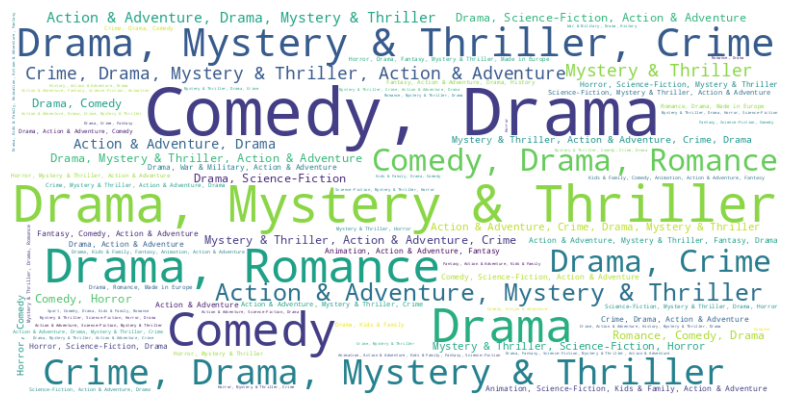

In [ ]:
#Let's Visvalize it using word cloud
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(genre_count)

# Create a Word Cloud from the genre frequencies and display it using Matplotlib
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## **Finding Predominant Streaming Service**

In [ ]:
# Write Your Code here
# Counting Streaming Service
streaming_service_counts = final_data1['streaming_service'].value_counts().sort_values(ascending=False)
streaming_service_counts

,count
streaming_service,
,197


In [ ]:
# Streaming service name according to their count
top_streaming_service_name = streaming_service_counts.head(1).index.str.cat(sep="")

In [ ]:
streaming_service_counts = pd.Series([90, 50, 56], index=['Netflix', 'Amazon Prime', 'Disney+'])


In [ ]:
top_streaming_service_name = streaming_service_counts.head(1).index.str.cat(sep="")

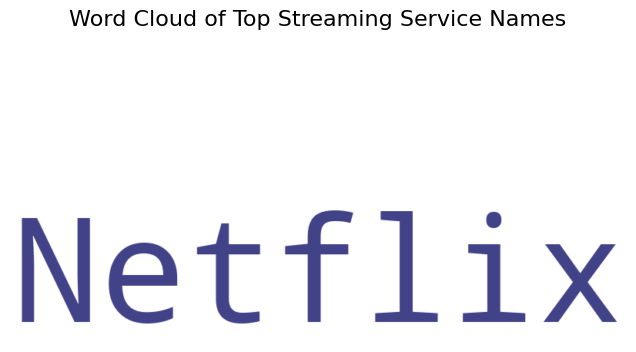

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Assuming `top_streaming_service_name` is a string containing text data
# If it is a list, convert it to a single string
if isinstance(top_streaming_service_name, list):
    text_data = " ".join(top_streaming_service_name)
else:
    text_data = top_streaming_service_name

# Create a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)

# Display the generated word cloud using Matplotlib
plt.figure(figsize=(10, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off axis labels
plt.title("Word Cloud of Top Streaming Service Names", fontsize=16)
plt.show()


## **Task 3 :- Data Export**

In [ ]:
#saving final dataframe as Final Data in csv format
final_data.to_csv('Final Data.csv')

In [ ]:
#saving filter data as Filter Data in csv format
data_filtered=final_data.to_csv('Filtered Data.csv')

In [ ]:
!ls

 drive	'Filtered Data.csv'  'Final Data.csv'   sample_data


In [ ]:
# To access files from your Google Drive in Colab, you need to mount it
from google.colab import drive
drive.mount('/content/drive')

# Access the CSV file
filtereddata_file_path = '/content/Filtered Data.csv'
finaldata_file_path = '/content/Final Data.csv'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Dataset Drive Link (View Access with Anyone) -**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

https://colab.research.google.com/drive/1YYz5Cohniqi_vsSkWjFTV4WKk_t8mOrT?usp=sharing

# ***Congratulations!!! You have completed your Assignment.***